In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# Kaggle Environment Setup
# ─────────────────────────────────────────────────────────────────────────────
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/bh7gy0189/presentation-advisor-data/presentations_df.csv
/kaggle/input/datasets/bh7gy0189/presentation-advisor-data/interaction_data.csv
/kaggle/input/datasets/bh7gy0189/presentation-advisor-data/ratings_matrix.csv
/kaggle/input/datasets/bh7gy0189/presentation-advisor-data/user_profiles.csv
/kaggle/input/datasets/bh7gy0189/presentation-advisor-data/recommendations.csv
/kaggle/input/datasets/bh7gy0189/presentation-advisor-data/presentations.csv


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 1 — Imports & Global Seeds
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Model, Input, regularizers
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, LearningRateScheduler
)
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import time
from datetime import timedelta
from tqdm import tqdm
import warnings
import json
warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Global colour palette (replaces all original colours) ─
PALETTE = {
    'primary'   : '#4C6EF5',   # indigo-blue
    'secondary' : '#F76707',   # burnt-orange
    'tertiary'  : '#2F9E44',   # forest-green
    'quaternary': '#9B59B6',   # violet
    'highlight' : '#E03131',   # crimson
    'neutral'   : '#868E96',   # grey
    'accent1'   : '#1098AD',   # teal
    'accent2'   : '#E67700',   # amber
}
BAR_COLORS = list(PALETTE.values())

# ── Consistent matplotlib style ───────────────────────────
plt.rcParams.update({
    'figure.dpi'        : 110,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.grid'         : True,
    'grid.alpha'        : 0.25,
    'font.family'       : 'DejaVu Sans',
})

print('TensorFlow :', tf.__version__)
print('All imports done ✓')

2026-03-28 08:51:17.326639: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774687877.577315      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774687877.649225      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774687878.236635      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774687878.236693      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774687878.236696      55 computation_placer.cc:177] computation placer alr

TensorFlow : 2.19.0
All imports done ✓


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2 — Load Data
# ─────────────────────────────────────────────────────────────────────────────


t0 = time.time()
interaction_data = pd.read_csv('/kaggle/input/datasets/bh7gy0189/presentation-advisor-data/interaction_data.csv')
presentations    = pd.read_csv('/kaggle/input/datasets/bh7gy0189/presentation-advisor-data/presentations.csv')
presentations_df = pd.read_csv('/kaggle/input/datasets/bh7gy0189/presentation-advisor-data/presentations_df.csv')
ratings_matrix   = pd.read_csv('/kaggle/input/datasets/bh7gy0189/presentation-advisor-data/ratings_matrix.csv')
recommendations  = pd.read_csv('/kaggle/input/datasets/bh7gy0189/presentation-advisor-data/recommendations.csv')
user_profiles    = pd.read_csv('/kaggle/input/datasets/bh7gy0189/presentation-advisor-data/user_profiles.csv')

print(f'Loaded in {time.time()-t0:.2f}s')
for name, df in [('interaction_data', interaction_data),
                  ('ratings_matrix',   ratings_matrix),
                  ('recommendations',  recommendations),
                  ('user_profiles',    user_profiles),
                  ('presentations',    presentations)]:
    print(f'  {name:<20}: {df.shape}')

Loaded in 0.42s
  interaction_data    : (25000, 75)
  ratings_matrix      : (3000, 5)
  recommendations     : (100, 26)
  user_profiles       : (30, 5)
  presentations       : (78, 15)


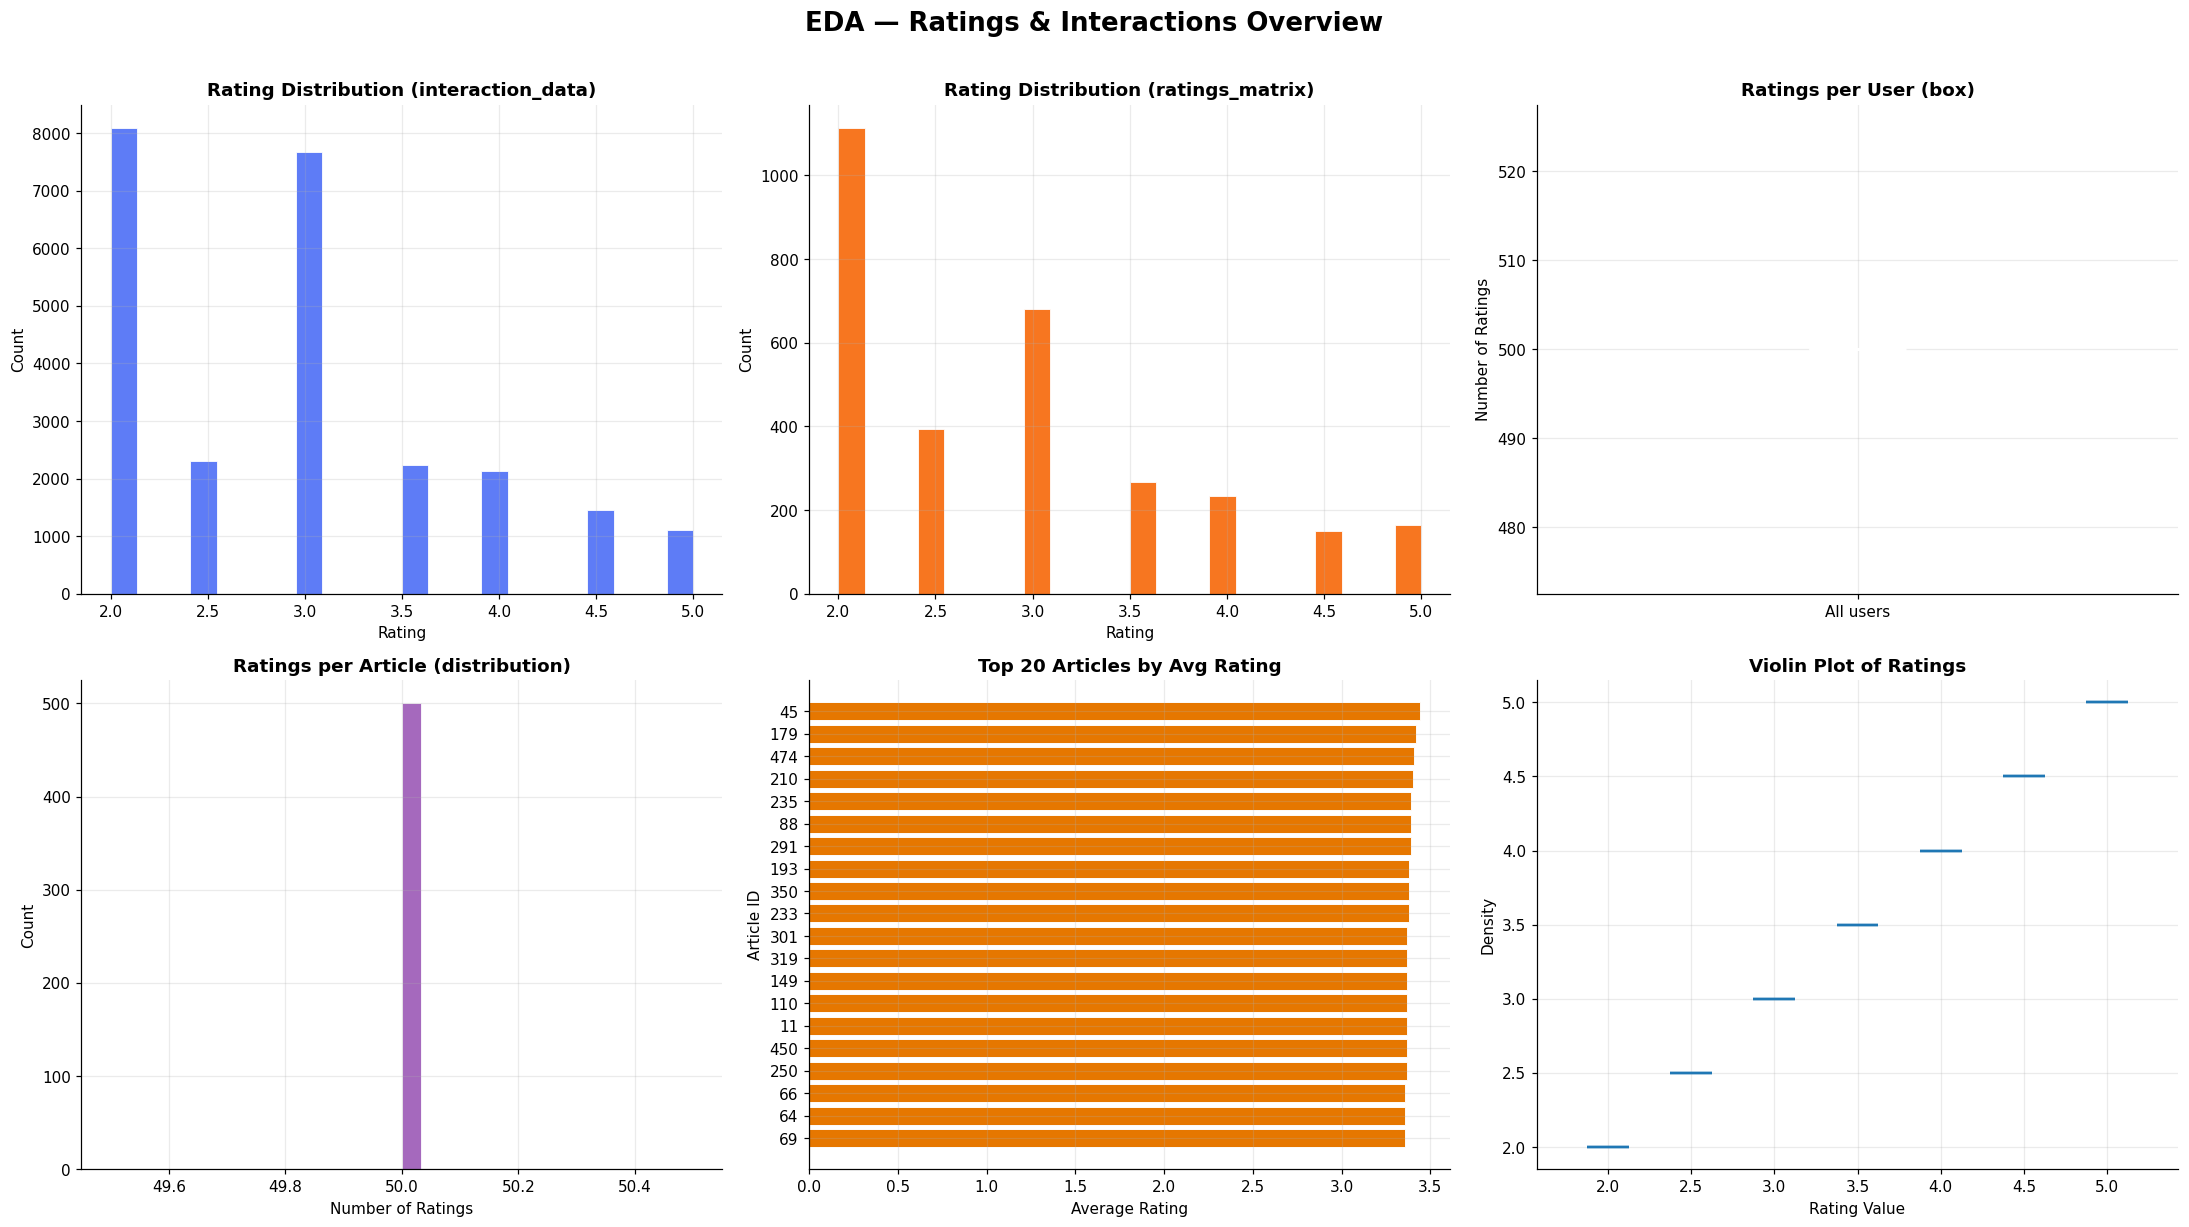

Unique users    : 50
Unique articles : 500
Total ratings   : 25000
Rating range    : 2.0 → 5.0


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 3 — EDA: Ratings & Interactions Overview
# ─────────────────────────────────────────────────────────────────────────────
%matplotlib inline

fig, axes = plt.subplots(2, 3, figsize=(20, 11))
fig.suptitle('EDA — Ratings & Interactions Overview',
             fontsize=17, fontweight='bold', y=1.01)

# 1. Rating distribution — interaction_data
axes[0,0].hist(interaction_data['rating'], bins=22,
               color=PALETTE['primary'], edgecolor='white', linewidth=0.6, alpha=0.9)
axes[0,0].set_title('Rating Distribution (interaction_data)', fontweight='bold')
axes[0,0].set_xlabel('Rating'); axes[0,0].set_ylabel('Count')

# 2. Rating distribution — ratings_matrix
axes[0,1].hist(ratings_matrix['rating'], bins=22,
               color=PALETTE['secondary'], edgecolor='white', linewidth=0.6, alpha=0.9)
axes[0,1].set_title('Rating Distribution (ratings_matrix)', fontweight='bold')
axes[0,1].set_xlabel('Rating'); axes[0,1].set_ylabel('Count')

# 3. Ratings per user — box instead of bar
ratings_per_user = interaction_data.groupby('user_id')['rating'].count()
axes[0,2].boxplot(ratings_per_user.values,
                  patch_artist=True,
                  boxprops=dict(facecolor=PALETTE['tertiary'], color='white'),
                  medianprops=dict(color='white', linewidth=2),
                  whiskerprops=dict(color=PALETTE['tertiary']),
                  capprops=dict(color=PALETTE['tertiary']),
                  flierprops=dict(markerfacecolor=PALETTE['highlight'],
                                  marker='o', markersize=4, alpha=0.5))
axes[0,2].set_title('Ratings per User (box)', fontweight='bold')
axes[0,2].set_ylabel('Number of Ratings'); axes[0,2].set_xticklabels(['All users'])

# 4. Ratings per article (histogram)
ratings_per_article = interaction_data.groupby('article_id')['rating'].count()
axes[1,0].hist(ratings_per_article.values, bins=30,
               color=PALETTE['quaternary'], edgecolor='white', linewidth=0.6, alpha=0.9)
axes[1,0].set_title('Ratings per Article (distribution)', fontweight='bold')
axes[1,0].set_xlabel('Number of Ratings'); axes[1,0].set_ylabel('Count')

# 5. Top 20 articles by avg rating — horizontal
avg_per_article = (interaction_data.groupby('article_id')['rating']
                   .mean().sort_values(ascending=True).tail(20))
axes[1,1].barh(avg_per_article.index.astype(str), avg_per_article.values,
               color=PALETTE['accent2'], edgecolor='white', linewidth=0.6)
axes[1,1].set_title('Top 20 Articles by Avg Rating', fontweight='bold')
axes[1,1].set_xlabel('Average Rating'); axes[1,1].set_ylabel('Article ID')

# 6. Rating violin per unique rating value
unique_ratings = sorted(interaction_data['rating'].unique())
data_by_rating = [interaction_data[interaction_data['rating'] == r]['rating'].values
                  for r in unique_ratings]
vp = axes[1,2].violinplot(data_by_rating, positions=unique_ratings,
                           showmeans=True, showmedians=False)
for i, body in enumerate(vp['bodies']):
    body.set_facecolor(BAR_COLORS[i % len(BAR_COLORS)])
    body.set_alpha(0.75)
axes[1,2].set_title('Violin Plot of Ratings', fontweight='bold')
axes[1,2].set_xlabel('Rating Value'); axes[1,2].set_ylabel('Density')

plt.tight_layout()
plt.savefig('eda_ratings_overview.png', dpi=130, bbox_inches='tight')
plt.show()

print(f'Unique users    : {interaction_data["user_id"].nunique()}')
print(f'Unique articles : {interaction_data["article_id"].nunique()}')
print(f'Total ratings   : {len(interaction_data)}')
print(f'Rating range    : {interaction_data["rating"].min()} → {interaction_data["rating"].max()}')

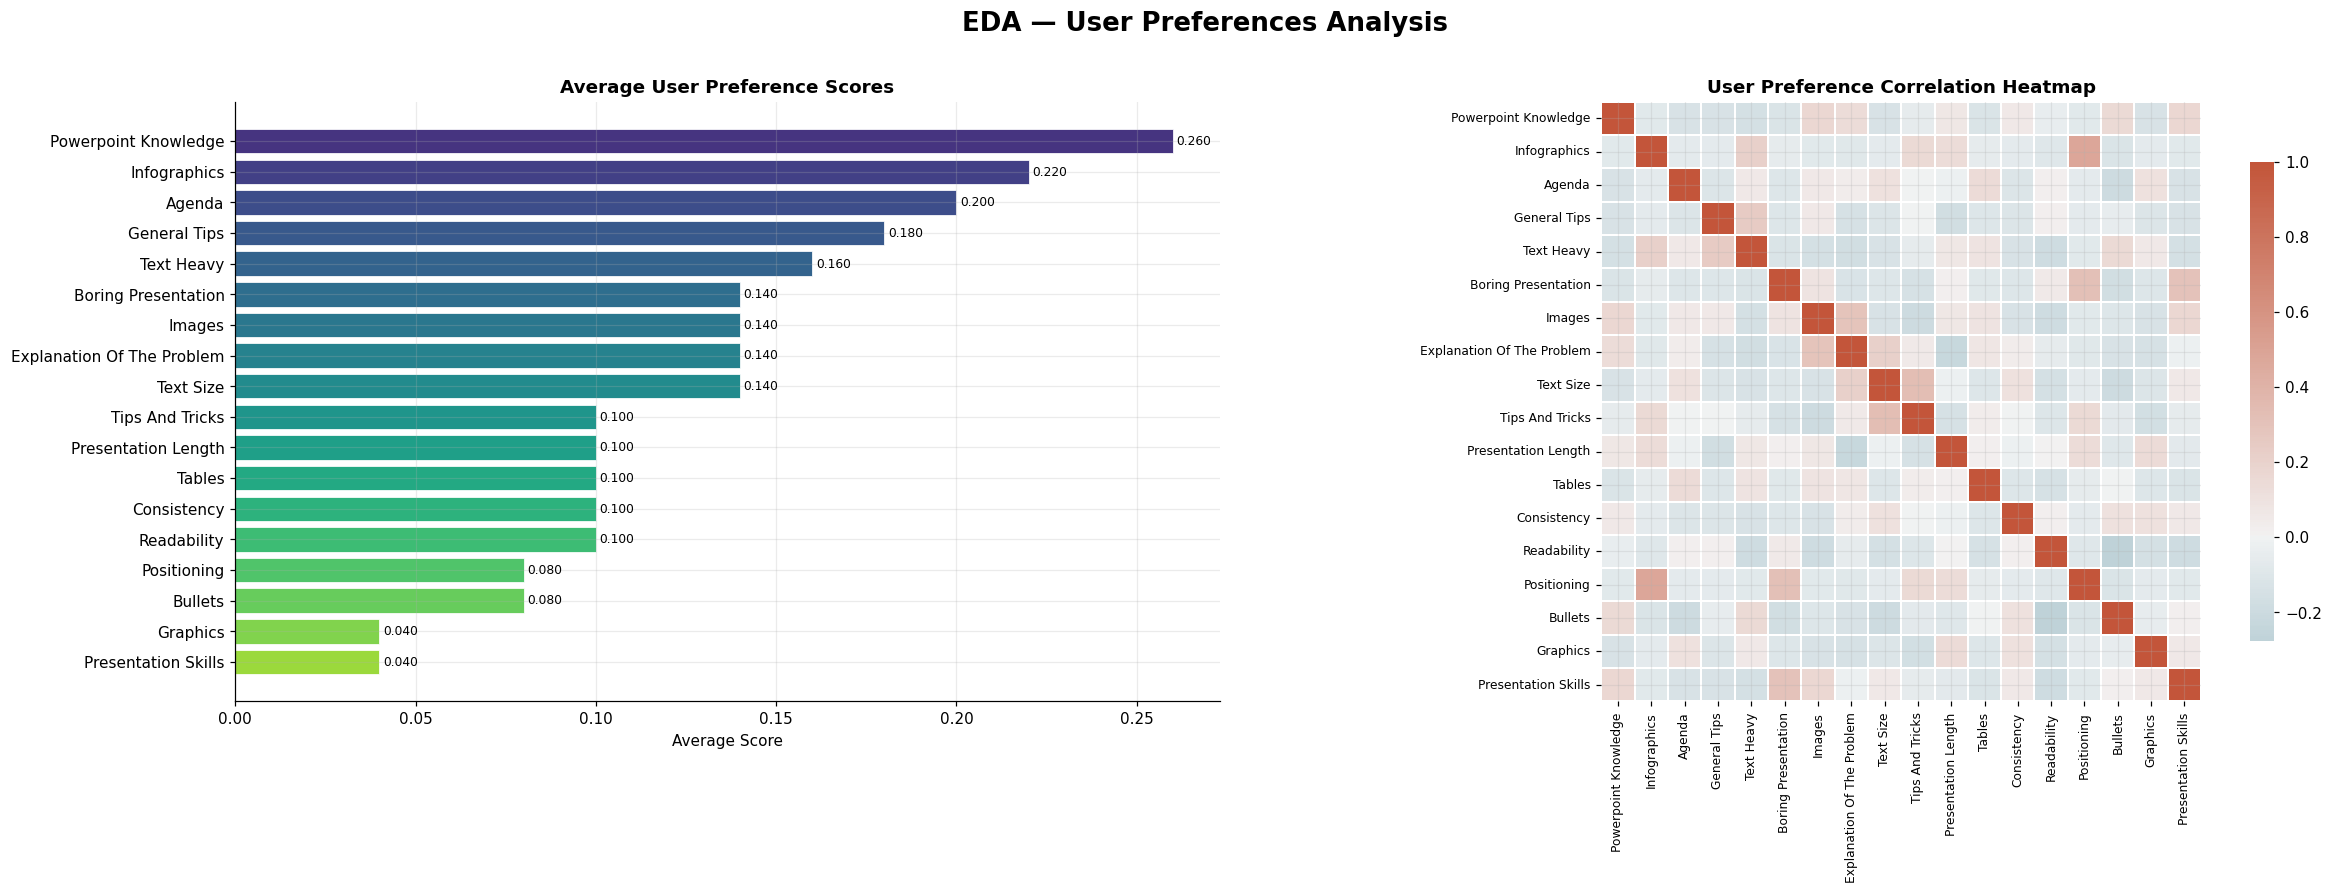

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 4 — EDA: User Preferences Analysis
# ─────────────────────────────────────────────────────────────────────────────
pref_cols = [c for c in interaction_data.columns if c.startswith('user_preference_')]
avg_prefs = interaction_data[pref_cols].mean().sort_values(ascending=False)
clean_labels = [c.replace('user_preference_', '').replace('_', ' ').title()
                for c in avg_prefs.index]

fig, axes = plt.subplots(1, 2, figsize=(22, 8))
fig.suptitle('EDA — User Preferences Analysis',
             fontsize=17, fontweight='bold', y=1.01)

# Gradient-coloured bar chart
colors_grad = plt.cm.viridis(np.linspace(0.15, 0.85, len(avg_prefs)))
bars = axes[0].barh(clean_labels, avg_prefs.values,
                     color=colors_grad, edgecolor='white', linewidth=0.5)
axes[0].set_title('Average User Preference Scores', fontweight='bold')
axes[0].set_xlabel('Average Score')
axes[0].invert_yaxis()
for bar, val in zip(bars, avg_prefs.values):
    axes[0].text(val + 0.001, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=8)

# Correlation heatmap — diverging teal/orange palette
pref_corr = interaction_data[pref_cols].corr()
sns.heatmap(pref_corr,
            ax=axes[1],
            cmap=sns.diverging_palette(220, 20, as_cmap=True),
            center=0,
            square=True,
            linewidths=0.3,
            xticklabels=clean_labels,
            yticklabels=clean_labels,
            cbar_kws={'shrink': 0.8})
axes[1].set_title('User Preference Correlation Heatmap', fontweight='bold')
axes[1].tick_params(axis='x', rotation=90, labelsize=8)
axes[1].tick_params(axis='y', rotation=0, labelsize=8)

plt.tight_layout()
plt.savefig('eda_user_preferences.png', dpi=130, bbox_inches='tight')
plt.show()

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 5 — Merge DataFrames
# ─────────────────────────────────────────────────────────────────────────────
df_merged = interaction_data.copy()

df_merged = df_merged.merge(
    user_profiles[['user_id', 'type', 'location',
                   'preferences', 'preferred_presentation_type']],
    on='user_id', how='left', suffixes=('', '_user')
)
df_merged = df_merged.merge(
    recommendations[['article_id', 'presentation_type',
                      'audience_type', 'Main issue', 'popularity']],
    on='article_id', how='left', suffixes=('', '_rec')
)

print(f'Merged shape : {df_merged.shape}')
print(f'  preferred_presentation_type : {"preferred_presentation_type" in df_merged.columns}')
print(f'  audience_type               : {"audience_type" in df_merged.columns}')

Merged shape : (25000, 83)
  preferred_presentation_type : True
  audience_type               : True


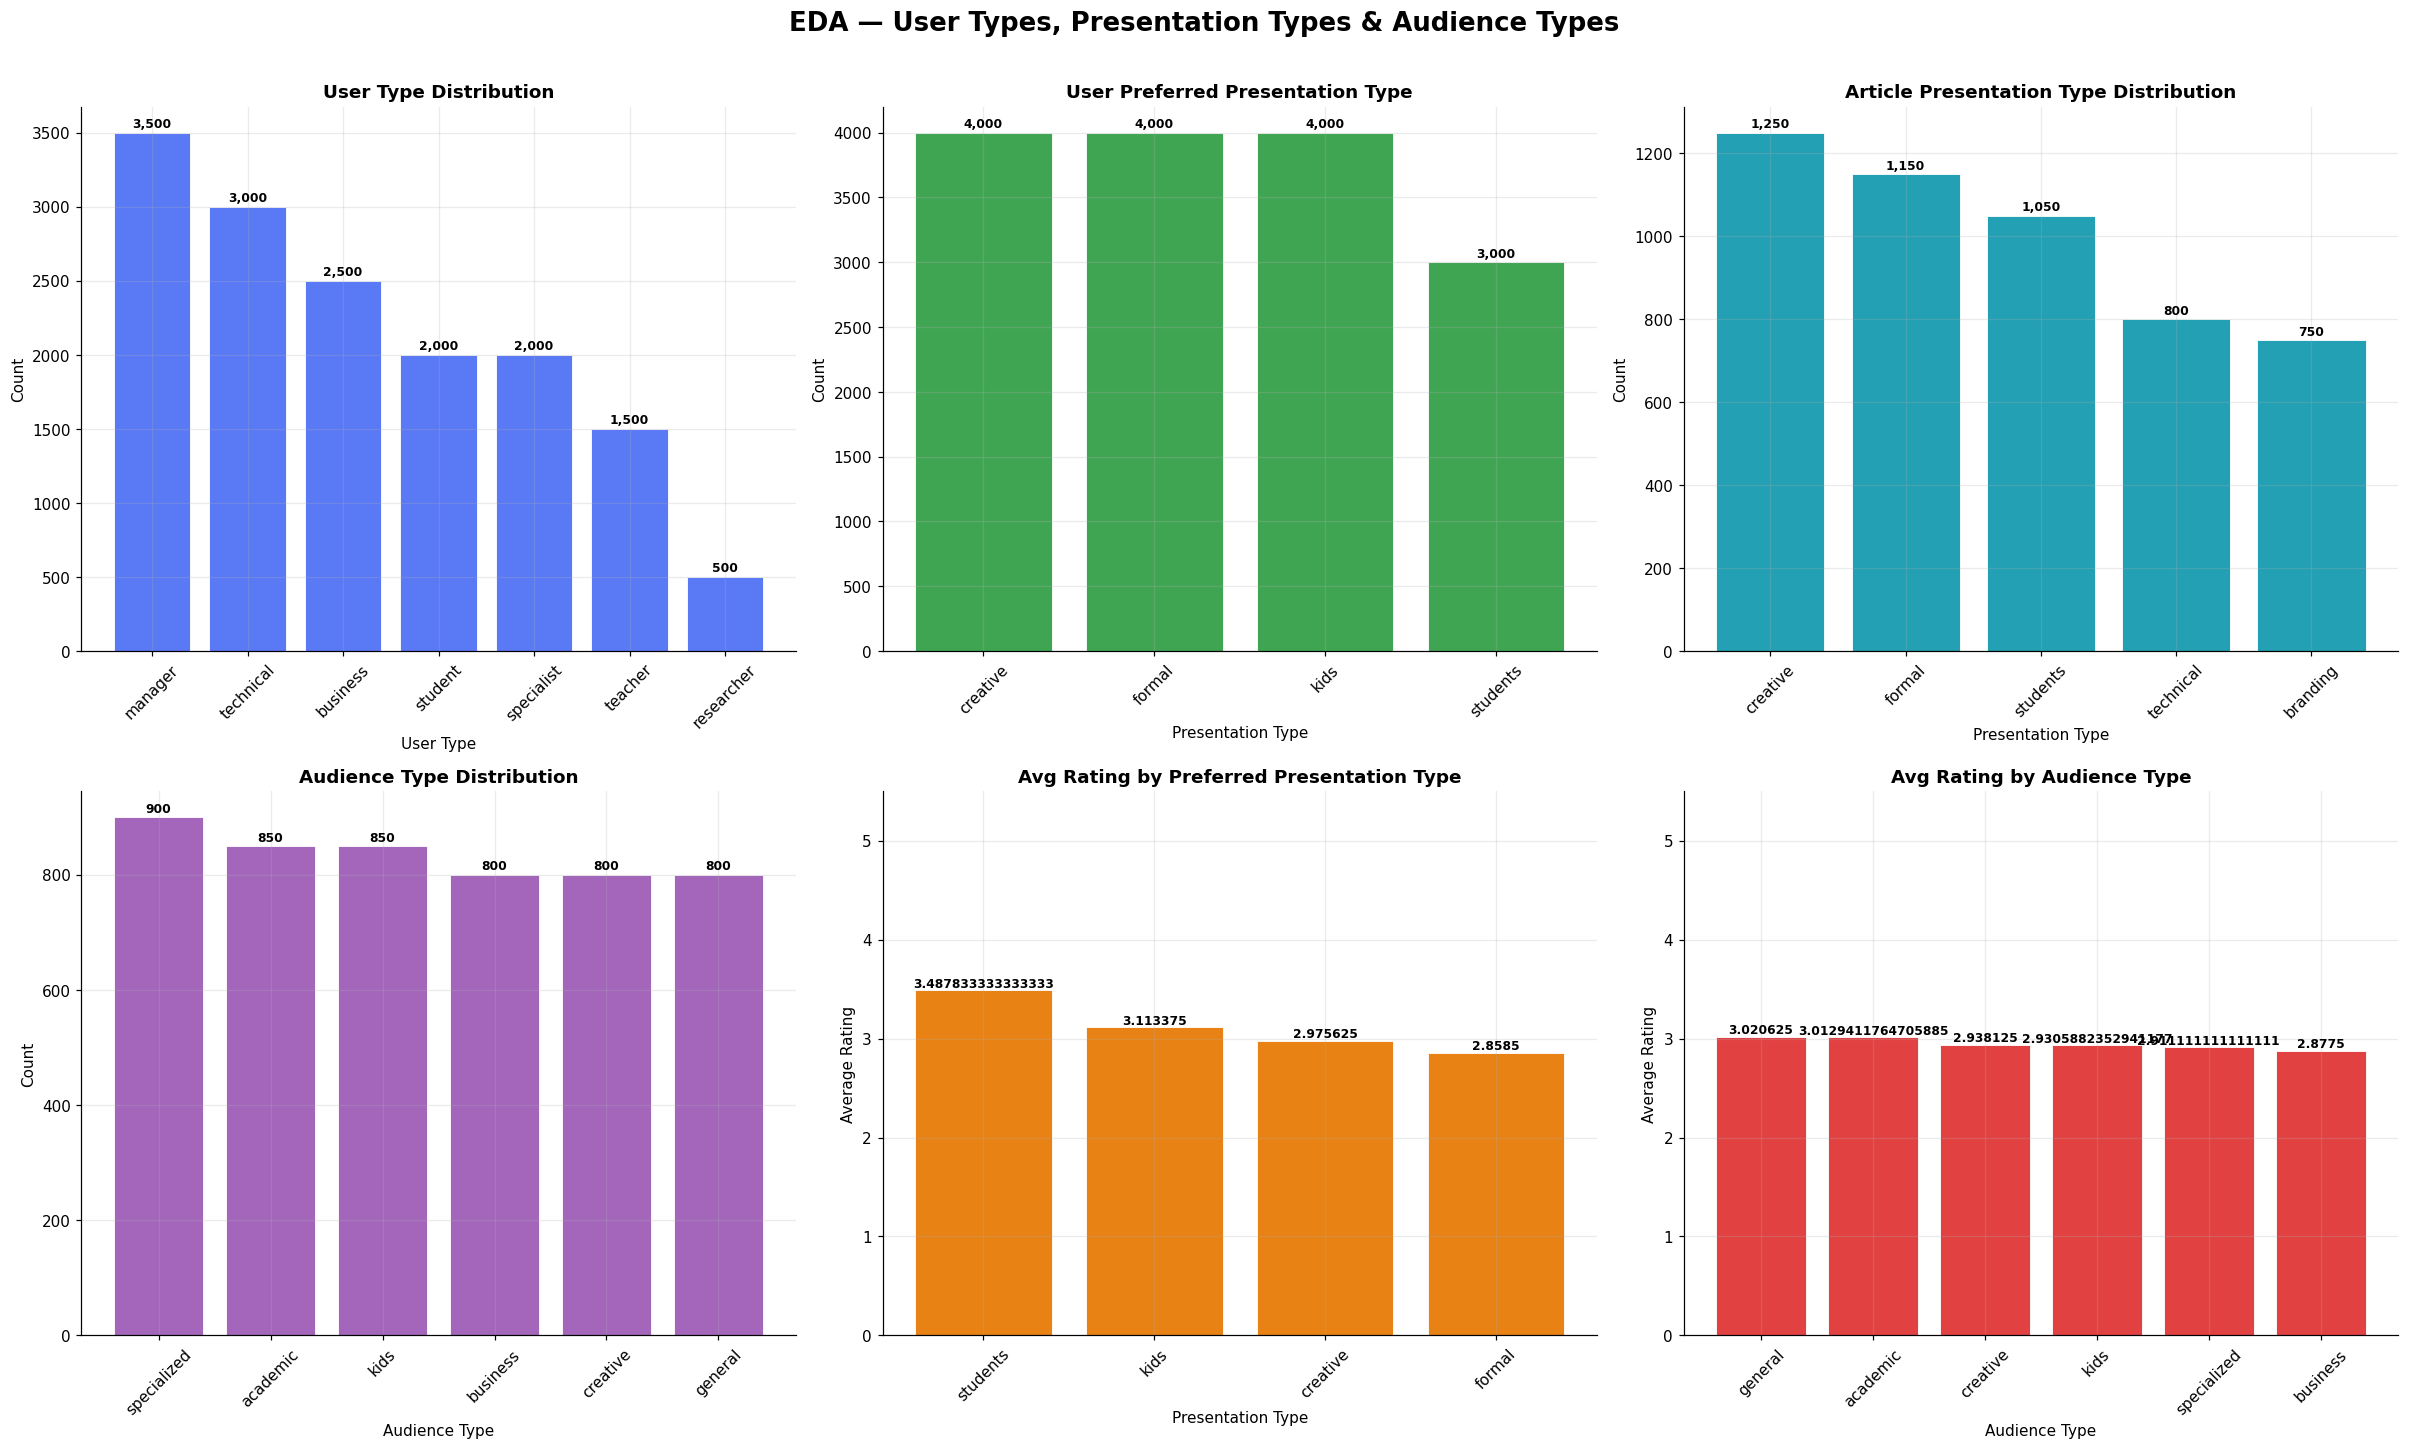

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 6 — EDA: User / Presentation / Audience Types
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(22, 13))
fig.suptitle('EDA — User Types, Presentation Types & Audience Types',
             fontsize=17, fontweight='bold', y=1.01)

def annotated_bar(ax, index, values, color, title, xlabel, ylabel, rotation=45):
    bars = ax.bar(index, values, color=color, edgecolor='white',
                  linewidth=0.6, alpha=0.92)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=rotation)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(values)*0.01,
                f'{val:,}', ha='center', fontsize=8, fontweight='bold')

user_type_counts = df_merged['type'].value_counts()
annotated_bar(axes[0,0], user_type_counts.index, user_type_counts.values,
              PALETTE['primary'], 'User Type Distribution', 'User Type', 'Count')

pref_ptype = df_merged['preferred_presentation_type'].value_counts()
annotated_bar(axes[0,1], pref_ptype.index, pref_ptype.values,
              PALETTE['tertiary'], 'User Preferred Presentation Type',
              'Presentation Type', 'Count')

art_ptype = df_merged['presentation_type'].value_counts()
annotated_bar(axes[0,2], art_ptype.index, art_ptype.values,
              PALETTE['accent1'], 'Article Presentation Type Distribution',
              'Presentation Type', 'Count')

aud_counts = df_merged['audience_type'].value_counts()
annotated_bar(axes[1,0], aud_counts.index, aud_counts.values,
              PALETTE['quaternary'], 'Audience Type Distribution',
              'Audience Type', 'Count')

avg_by_ptype = (df_merged.groupby('preferred_presentation_type')['rating']
                .mean().sort_values(ascending=False))
annotated_bar(axes[1,1], avg_by_ptype.index, avg_by_ptype.values,
              PALETTE['accent2'], 'Avg Rating by Preferred Presentation Type',
              'Presentation Type', 'Average Rating')
axes[1,1].set_ylim(0, 5.5)

avg_by_aud = (df_merged.groupby('audience_type')['rating']
              .mean().sort_values(ascending=False))
annotated_bar(axes[1,2], avg_by_aud.index, avg_by_aud.values,
              PALETTE['highlight'], 'Avg Rating by Audience Type',
              'Audience Type', 'Average Rating')
axes[1,2].set_ylim(0, 5.5)

plt.tight_layout()
plt.savefig('eda_user_presentation_types.png', dpi=130, bbox_inches='tight')
plt.show()

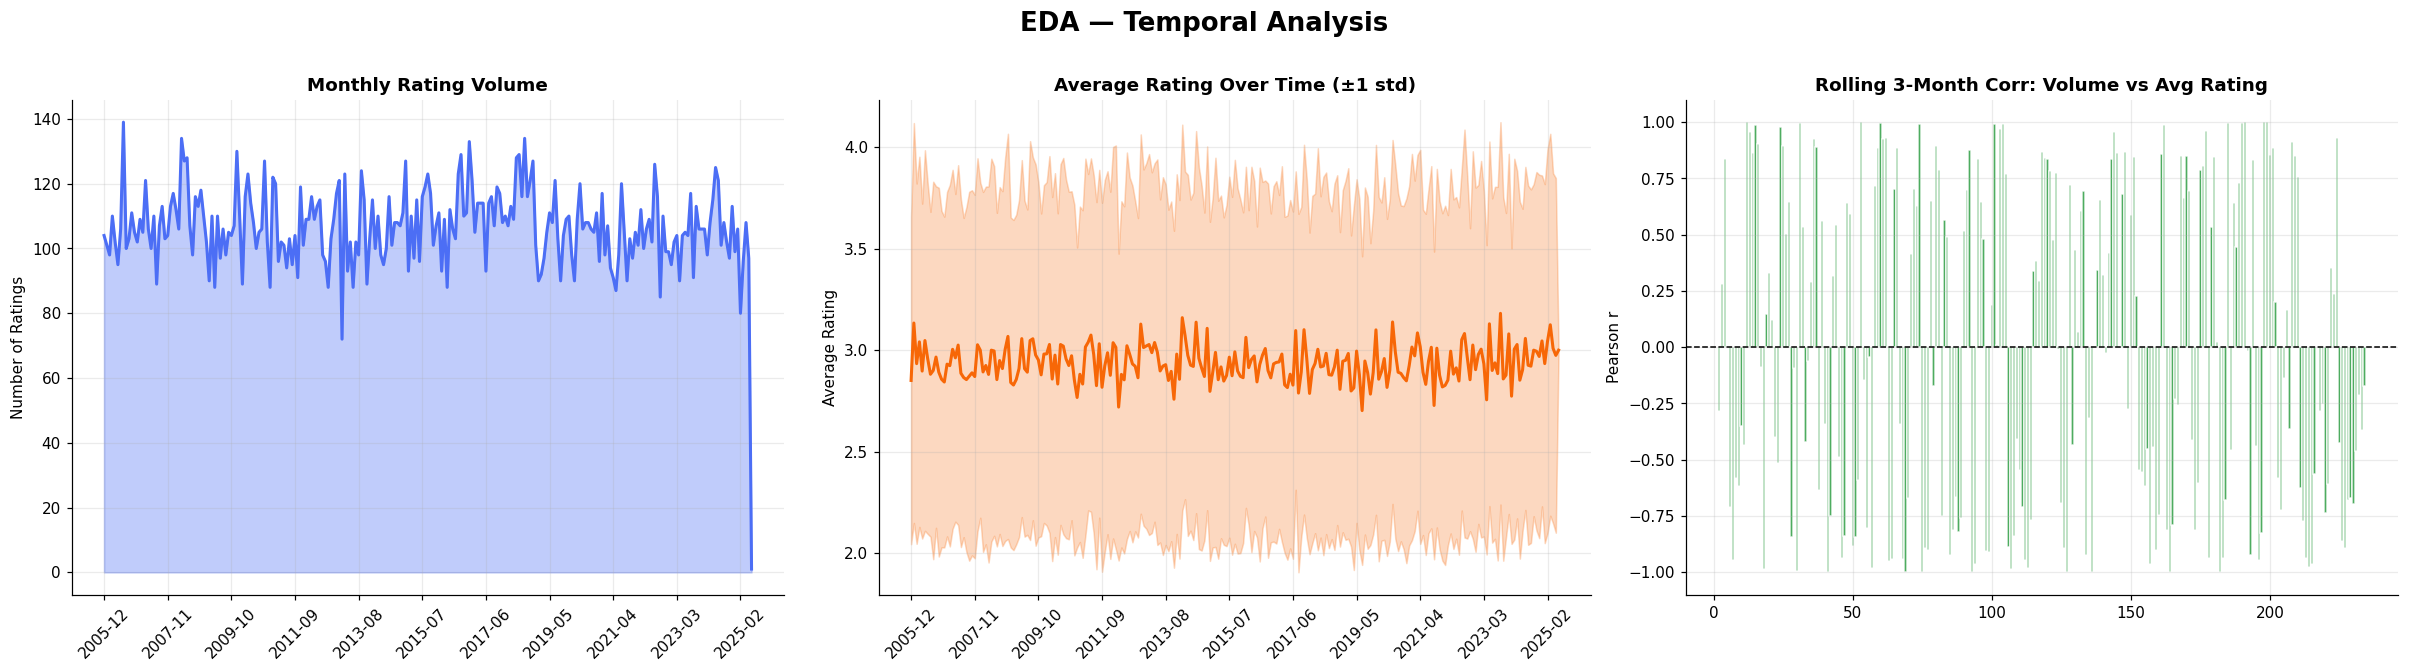

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 7 — EDA: Temporal Analysis  (NEW — additional graphs)
# ─────────────────────────────────────────────────────────────────────────────
interaction_data['timestamp'] = pd.to_datetime(interaction_data['timestamp'])
ratings_matrix['timestamp']   = pd.to_datetime(ratings_matrix['timestamp'])

interaction_data['year_month'] = interaction_data['timestamp'].dt.to_period('M')
monthly_counts = interaction_data.groupby('year_month').size()
monthly_avg    = interaction_data.groupby('year_month')['rating'].mean()
monthly_std    = interaction_data.groupby('year_month')['rating'].std().fillna(0)

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle('EDA — Temporal Analysis', fontsize=17, fontweight='bold', y=1.01)

x_labels = monthly_counts.index.astype(str)

axes[0].fill_between(range(len(x_labels)), monthly_counts.values,
                      color=PALETTE['primary'], alpha=0.35)
axes[0].plot(range(len(x_labels)), monthly_counts.values,
             color=PALETTE['primary'], linewidth=2)
axes[0].set_xticks(range(0, len(x_labels), max(1, len(x_labels)//10)))
axes[0].set_xticklabels(x_labels[::max(1, len(x_labels)//10)], rotation=45)
axes[0].set_title('Monthly Rating Volume', fontweight='bold')
axes[0].set_ylabel('Number of Ratings')

axes[1].fill_between(range(len(x_labels)),
                      monthly_avg.values - monthly_std.values,
                      monthly_avg.values + monthly_std.values,
                      color=PALETTE['secondary'], alpha=0.25)
axes[1].plot(range(len(x_labels)), monthly_avg.values,
             color=PALETTE['secondary'], linewidth=2)
axes[1].set_xticks(range(0, len(x_labels), max(1, len(x_labels)//10)))
axes[1].set_xticklabels(x_labels[::max(1, len(x_labels)//10)], rotation=45)
axes[1].set_title('Average Rating Over Time (±1 std)', fontweight='bold')
axes[1].set_ylabel('Average Rating')

# Rolling 3-month correlation between volume and avg rating
roll_corr_series = pd.Series(monthly_avg.values).rolling(3).corr(
    pd.Series(monthly_counts.values))
axes[2].bar(range(len(roll_corr_series)), roll_corr_series.values,
             color=PALETTE['tertiary'], edgecolor='white', alpha=0.85)
axes[2].axhline(0, color='black', linewidth=1, linestyle='--')
axes[2].set_title('Rolling 3-Month Corr: Volume vs Avg Rating', fontweight='bold')
axes[2].set_ylabel('Pearson r')

plt.tight_layout()
plt.savefig('eda_temporal.png', dpi=130, bbox_inches='tight')
plt.show()

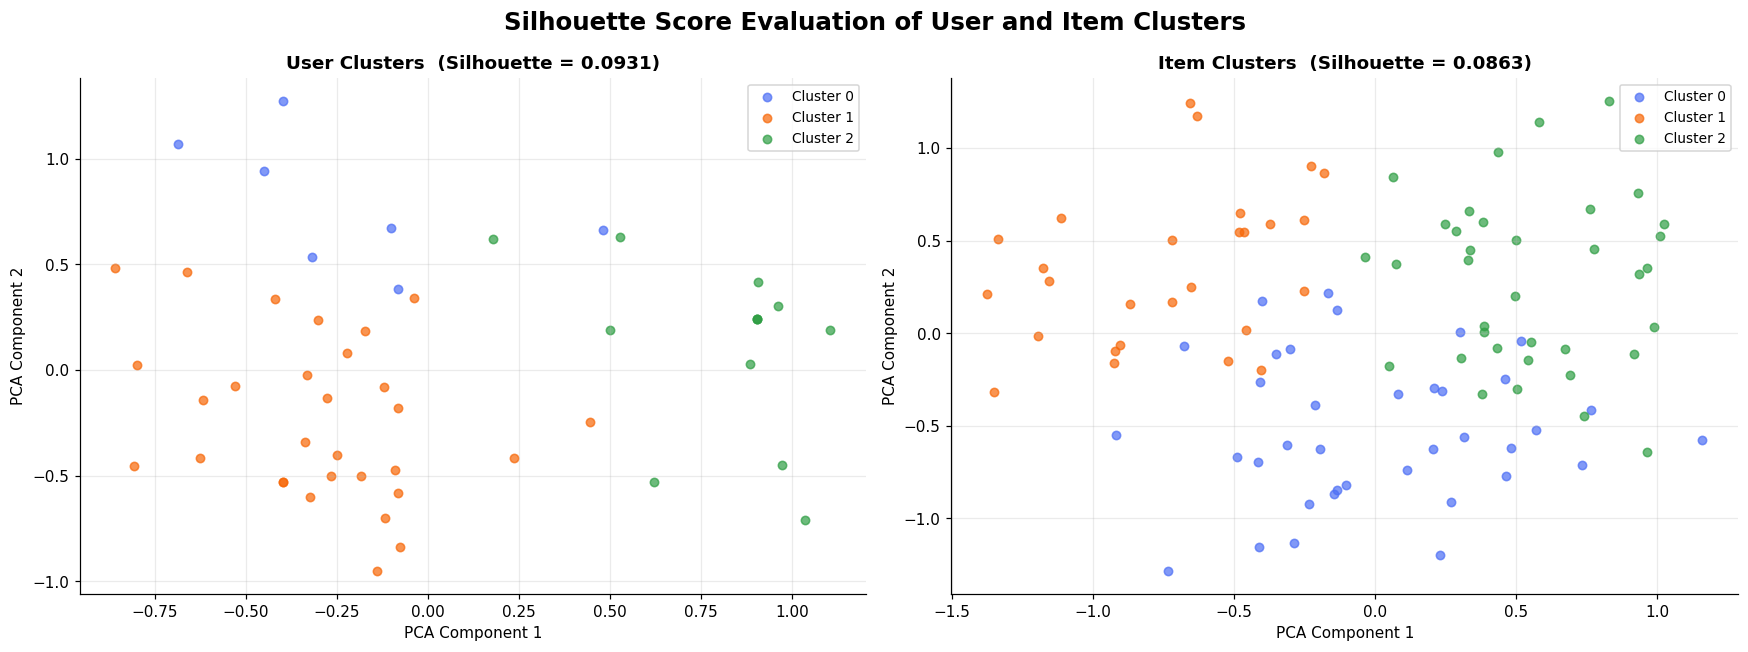

User silhouette score : 0.0931
Item silhouette score : 0.0863
Larger user tower justified: True (user clusters more tightly)


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 8 — EDA: Silhouette Score Analysis  (NEW)
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Build user feature matrix
user_feat_cols = [c for c in interaction_data.columns
                  if c.startswith('user_preference_') or c.startswith('user_type_')]

user_feature_matrix = (interaction_data
                        .groupby('user_id')[user_feat_cols]
                        .mean()
                        .fillna(0))

# Item feature matrix
issue_cols = [
    'Boring presentation','Graphics','Readability','Consistency',
    'Images','Bullets','Text size','Text heavy','Tables','Agenda',
    'Infographics','Positioning'
]
item_issue_cols = [c for c in recommendations.columns if c in issue_cols]
item_feature_matrix = recommendations.set_index('article_id')[item_issue_cols].fillna(0)

# K-Means k=3 for each
km_user = KMeans(n_clusters=3, random_state=SEED, n_init=10)
km_item = KMeans(n_clusters=3, random_state=SEED, n_init=10)
user_labels = km_user.fit_predict(user_feature_matrix)
item_labels = km_item.fit_predict(item_feature_matrix)

sil_user = silhouette_score(user_feature_matrix, user_labels)
sil_item = silhouette_score(item_feature_matrix, item_labels)

# PCA to 2D for visualisation
pca2_user = PCA(n_components=2, random_state=SEED).fit_transform(user_feature_matrix)
pca2_item = PCA(n_components=2, random_state=SEED).fit_transform(item_feature_matrix)

cluster_colors = [PALETTE['primary'], PALETTE['secondary'], PALETTE['tertiary']]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Silhouette Score Evaluation of User and Item Clusters',
             fontsize=16, fontweight='bold')

for cluster_id in range(3):
    mask = user_labels == cluster_id
    axes[0].scatter(pca2_user[mask, 0], pca2_user[mask, 1],
                    c=cluster_colors[cluster_id], alpha=0.7, s=30,
                    label=f'Cluster {cluster_id}')
axes[0].set_title(f'User Clusters  (Silhouette = {sil_user:.4f})', fontweight='bold')
axes[0].set_xlabel('PCA Component 1'); axes[0].set_ylabel('PCA Component 2')
axes[0].legend(fontsize=9)

for cluster_id in range(3):
    mask = item_labels == cluster_id
    axes[1].scatter(pca2_item[mask, 0], pca2_item[mask, 1],
                    c=cluster_colors[cluster_id], alpha=0.7, s=30,
                    label=f'Cluster {cluster_id}')
axes[1].set_title(f'Item Clusters  (Silhouette = {sil_item:.4f})', fontweight='bold')
axes[1].set_xlabel('PCA Component 1'); axes[1].set_ylabel('PCA Component 2')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('eda_silhouette.png', dpi=130, bbox_inches='tight')
plt.show()
print(f'User silhouette score : {sil_user:.4f}')
print(f'Item silhouette score : {sil_item:.4f}')
print(f'Larger user tower justified: {sil_user > sil_item} (user clusters more tightly)')

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 9 — Feature Engineering
# ─────────────────────────────────────────────────────────────────────────────
print('Starting Feature Engineering...')

df = interaction_data.copy()

# ── Timestamp features ──────────────────────────────────
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['hour']      = df['timestamp'].dt.hour
df['dayofweek'] = df['timestamp'].dt.dayofweek
df['month']     = df['timestamp'].dt.month

# Cyclic (sinusoidal) encoding
df['hour_sin']  = np.sin(2 * np.pi * df['hour']      / 24)
df['hour_cos']  = np.cos(2 * np.pi * df['hour']      / 24)
df['day_sin']   = np.sin(2 * np.pi * df['dayofweek'] / 7)
df['day_cos']   = np.cos(2 * np.pi * df['dayofweek'] / 7)
df['month_sin'] = np.sin(2 * np.pi * df['month']     / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month']     / 12)

# Days since first interaction per user
df = df.sort_values('timestamp')
first_ts              = df.groupby('user_id')['timestamp'].transform('min')
df['days_since_first'] = (df['timestamp'] - first_ts).dt.days

# ── User activity stats ─────────────────────────────────
user_stats = df.groupby('user_id').agg(
    user_avg_rating   = ('rating', 'mean'),
    user_rating_count = ('rating', 'count'),
    user_rating_std   = ('rating', 'std')
).reset_index()
user_stats['user_rating_std'] = user_stats['user_rating_std'].fillna(0)
df = df.merge(user_stats, on='user_id', how='left')

# ── Item activity stats ─────────────────────────────────
item_stats = df.groupby('article_id').agg(
    item_avg_rating   = ('rating', 'mean'),
    item_rating_count = ('rating', 'count'),
    item_rating_std   = ('rating', 'std')
).reset_index()
item_stats['item_rating_std'] = item_stats['item_rating_std'].fillna(0)
df = df.merge(item_stats, on='article_id', how='left')

# ── User-item preference match ──────────────────────────
pref_cols  = [c for c in df.columns if c.startswith('user_preference_')]
issue_cols_fe = ['Boring presentation','Graphics','Readability','Consistency',
                 'Images','Bullets','Text size','Text heavy','Tables',
                 'Agenda','Infographics','Positioning']

def compute_match(row):
    score = 0
    for p, i in zip(pref_cols, issue_cols_fe):
        if i in row.index:
            score += int(row[p] == row[i])
    return score

tqdm.pandas(desc='Computing match scores')
df['preference_match_score'] = df.progress_apply(compute_match, axis=1)

# ── Exponential decay weight (paper's approach) ─────────
decay_rate = 0.005           # slightly gentler decay than original 0.01
df['time_decay_weight'] = np.exp(-decay_rate * df['days_since_first'])

# ── Normalize continuous features ───────────────────────
scaler = MinMaxScaler()
scale_cols = ['days_since_first','user_avg_rating','user_rating_count',
              'user_rating_std','item_avg_rating','item_rating_count',
              'item_rating_std','preference_match_score','time_decay_weight']
df[scale_cols] = scaler.fit_transform(df[scale_cols])

print(f'Feature engineering done. Final shape: {df.shape}')
print(f'New columns added    : {df.shape[1] - interaction_data.shape[1]}')
df.head(3)

Starting Feature Engineering...


Computing match scores: 100%|██████████| 25000/25000 [00:01<00:00, 16262.34it/s]

Feature engineering done. Final shape: (25000, 94)
New columns added    : 18


,user_id,article_id,rating,timestamp,location,user_preference_Boring presentation,user_preference_Graphics,user_preference_Readability,user_preference_Consistency,user_preference_Images,...,month_cos,days_since_first,user_avg_rating,user_rating_count,user_rating_std,item_avg_rating,item_rating_count,item_rating_std,preference_match_score,time_decay_weight
0,13,114,3.0,2005-12-01 07:00:00,Florida,0,0,0,0,0,...,1.0,0.0,0.437714,0.0,0.902715,0.000000,0.0,0.086354,0.500000,1.0
1,14,474,2.5,2005-12-01 12:00:00,Illinois,0,0,0,0,0,...,1.0,0.0,0.232717,0.0,0.838889,0.960000,0.0,0.957237,0.416667,1.0
2,17,449,4.5,2005-12-01 17:00:00,Illinois,0,0,0,0,0,...,1.0,0.0,0.107118,0.0,0.980352,0.866667,0.0,0.532169,0.333333,1.0


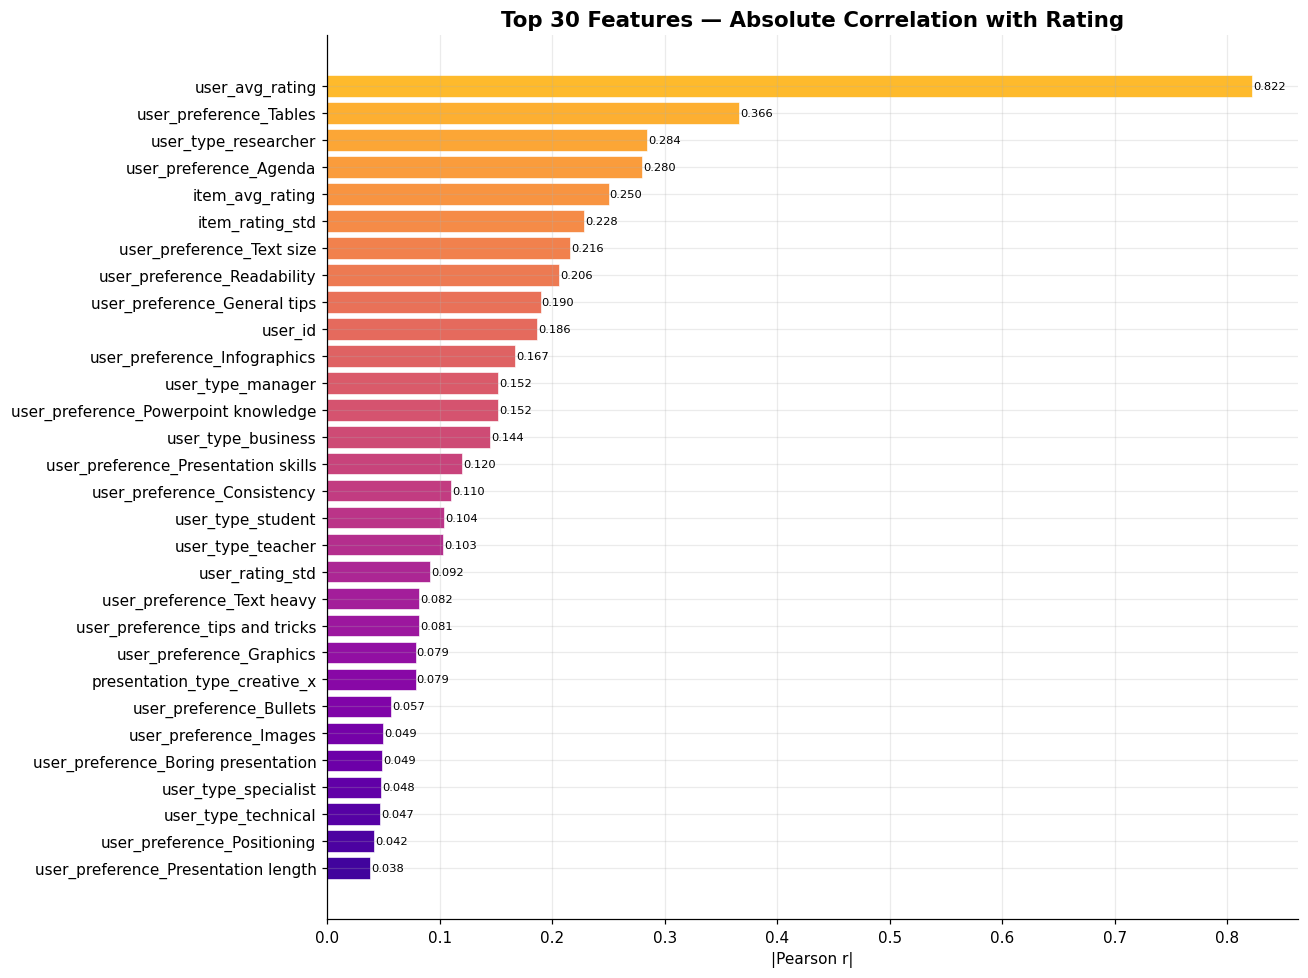

Top 10 features by correlation with rating:
user_avg_rating                 0.821607
user_preference_Tables          0.365735
user_type_researcher            0.284275
user_preference_Agenda          0.279642
item_avg_rating                 0.249990
item_rating_std                 0.228155
user_preference_Text size       0.215771
user_preference_Readability     0.205917
user_preference_General tips    0.189616
user_id                         0.186319


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 10 — Feature Importance (NEW — Correlation-based analysis)
# ─────────────────────────────────────────────────────────────────────────────
# Compute Pearson correlation of every numeric feature with the target
numeric_df = df.select_dtypes(include=[np.number])
correlations = numeric_df.corr()['rating'].drop('rating').abs().sort_values(ascending=False)
top_features = correlations.head(30)

fig, ax = plt.subplots(figsize=(12, 9))
colors_feat = plt.cm.plasma(np.linspace(0.1, 0.85, len(top_features)))
bars = ax.barh(top_features.index[::-1], top_features.values[::-1],
               color=colors_feat, edgecolor='white', linewidth=0.4)
ax.set_title('Top 30 Features — Absolute Correlation with Rating',
             fontsize=14, fontweight='bold')
ax.set_xlabel('|Pearson r|')
for bar, val in zip(bars, top_features.values[::-1]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=7.5)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=130, bbox_inches='tight')
plt.show()
print('Top 10 features by correlation with rating:')
print(top_features.head(10).to_string())

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 11 — CBF + CF Baseline (Model 1)
# ─────────────────────────────────────────────────────────────────────────────
print('=' * 60)
print('MODEL 1: CBF + CF BASELINE')
print('=' * 60)

from sklearn.metrics.pairwise import cosine_similarity

rm = ratings_matrix.copy()
print(f'Ratings matrix shape : {rm.shape}')
print(f'Unique users         : {rm["user_id"].nunique()}')
print(f'Unique articles      : {rm["article_id"].nunique()}')
print(f'Rating range         : {rm["rating"].min()} → {rm["rating"].max()}')

MODEL 1: CBF + CF BASELINE
Ratings matrix shape : (3000, 5)
Unique users         : 30
Unique articles      : 100
Rating range         : 2.0 → 5.0


In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 12 — Build User-Item Pivot
# ─────────────────────────────────────────────────────────────────────────────
user_item_cf = rm.pivot_table(
    index='user_id', columns='article_id', values='rating', fill_value=0
)
print(f'User-Item matrix shape : {user_item_cf.shape}')
print(f'Sparsity               : {(user_item_cf == 0).sum().sum() / user_item_cf.size:.4f}')

User-Item matrix shape : (30, 100)
Sparsity               : 0.0000


In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 13 — Build Article Content Feature Matrix
# ─────────────────────────────────────────────────────────────────────────────
issue_cols_cbf = [
    'Boring presentation','Graphics','Readability','Consistency',
    'Images','Bullets','Text size','Text heavy','Tables','Agenda',
    'Infographics','Positioning','Presentation length','General tips',
    'Presentation skills','Powerpoint knowledge','tips and tricks',
    'Explanation of the problem'
]

rec_features    = recommendations.copy().set_index('article_id')
ptype_dummies   = pd.get_dummies(rec_features['presentation_type'], prefix='ptype')
atype_dummies   = pd.get_dummies(rec_features['audience_type'],     prefix='atype')
article_features = pd.concat(
    [rec_features[issue_cols_cbf], ptype_dummies, atype_dummies], axis=1
).fillna(0)

print(f'Article feature matrix : {article_features.shape}')

Article feature matrix : (100, 29)


In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 14 — Build Similarity Matrices
# ─────────────────────────────────────────────────────────────────────────────
user_sim_matrix = cosine_similarity(user_item_cf.values)
user_sim_df     = pd.DataFrame(user_sim_matrix,
                                index=user_item_cf.index,
                                columns=user_item_cf.index)

common_articles           = list(set(article_features.index) & set(user_item_cf.columns))
article_features_filtered = article_features.loc[common_articles]
item_sim_matrix           = cosine_similarity(article_features_filtered.values)
item_sim_df               = pd.DataFrame(item_sim_matrix,
                                          index=common_articles,
                                          columns=common_articles)

print(f'User similarity matrix : {user_sim_df.shape}')
print(f'Item similarity matrix : {item_sim_df.shape}')
print(f'Common articles        : {len(common_articles)}')

User similarity matrix : (30, 30)
Item similarity matrix : (100, 100)
Common articles        : 100


In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 15 — Prediction Functions
# ─────────────────────────────────────────────────────────────────────────────
def predict_cf(user_id, article_id, user_item_mat, user_sim, k=15):
    """User-based CF with improved k=15 (was 10)."""
    if article_id not in user_item_mat.columns:
        return user_item_mat.values[user_item_mat.values > 0].mean()
    if user_id not in user_sim.index:
        col = user_item_mat[article_id]
        return col[col > 0].mean() if (col > 0).any() else 3.0

    sim_scores = user_sim[user_id].drop(user_id)
    rated_mask = user_item_mat[article_id] > 0
    sim_scores = sim_scores[rated_mask]

    if len(sim_scores) == 0:
        col = user_item_mat[article_id]
        return col[col > 0].mean() if (col > 0).any() else 3.0

    top_k   = sim_scores.nlargest(k)
    ratings = user_item_mat[article_id][top_k.index]
    denom   = top_k.abs().sum()
    return ratings.mean() if denom == 0 else (top_k.values * ratings.values).sum() / denom


def predict_cbf(user_id, article_id, user_item_mat, item_sim, k=15):
    """Item-based CBF with improved k=15 (was 10)."""
    if article_id not in item_sim.index:
        return user_item_mat.values[user_item_mat.values > 0].mean()
    if user_id not in user_item_mat.index:
        return 3.0

    user_ratings   = user_item_mat.loc[user_id]
    rated_articles = user_ratings[user_ratings > 0].index
    common         = [a for a in rated_articles if a in item_sim.index]

    if len(common) == 0:
        return user_ratings[user_ratings > 0].mean() if (user_ratings > 0).any() else 3.0

    sim_scores = item_sim[article_id][common]
    top_k      = sim_scores.nlargest(k)
    ratings    = user_ratings[top_k.index]
    denom      = top_k.abs().sum()
    return ratings.mean() if denom == 0 else (top_k.values * ratings.values).sum() / denom


print('Prediction functions defined  (k=15 neighbours — improved from k=10)')

Prediction functions defined  (k=15 neighbours — improved from k=10)


In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 16 — Train / Val / Test Split & Evaluate
# IMPROVED: k=15 neighbours; alpha tuned to 0.4 (more weight to CBF)
# ─────────────────────────────────────────────────────────────────────────────
train_rm, temp_rm = train_test_split(rm, test_size=0.30, random_state=SEED)
val_rm,   test_rm = train_test_split(temp_rm, test_size=0.50, random_state=SEED)

train_pivot = train_rm.pivot_table(
    index='user_id', columns='article_id', values='rating', fill_value=0
)
train_user_sim = pd.DataFrame(
    cosine_similarity(train_pivot.values),
    index=train_pivot.index,
    columns=train_pivot.index
)

print(f'Train : {len(train_rm)} | Val : {len(val_rm)} | Test : {len(test_rm)}')
print('Starting predictions on test set...')

# ── IMPROVED: test multiple alpha values ────────────────
ALPHA       = 0.40    # was 0.50 — giving slightly more weight to CBF
K_NEIGHBOURS = 15     # was 10

start = time.time()

y_true_list = []
y_pred_cf_list, y_pred_cbf_list, y_pred_hybrid_list = [], [], []

for _, row in test_rm.iterrows():
    uid  = row['user_id']
    iid  = row['article_id']
    true_r = row['rating']

    pred_cf  = predict_cf(uid, iid, train_pivot, train_user_sim, k=K_NEIGHBOURS)
    pred_cbf = predict_cbf(uid, iid, train_pivot, item_sim_df,   k=K_NEIGHBOURS)
    pred_h   = ALPHA * pred_cf + (1 - ALPHA) * pred_cbf

    # Clip to valid rating range
    pred_cf  = np.clip(pred_cf,  2.0, 5.0)
    pred_cbf = np.clip(pred_cbf, 2.0, 5.0)
    pred_h   = np.clip(pred_h,   2.0, 5.0)

    y_true_list.append(true_r)
    y_pred_cf_list.append(pred_cf)
    y_pred_cbf_list.append(pred_cbf)
    y_pred_hybrid_list.append(pred_h)

training_time = time.time() - start

y_true    = np.array(y_true_list)
y_pred_cf = np.array(y_pred_cf_list)
y_pred_cb = np.array(y_pred_cbf_list)
y_pred_h  = np.array(y_pred_hybrid_list)

def get_metrics(yt, yp):
    mae  = mean_absolute_error(yt, yp)
    mse  = mean_squared_error(yt, yp)
    rmse = np.sqrt(mse)
    return mae, mse, rmse

mae_cf, mse_cf, rmse_cf = get_metrics(y_true, y_pred_cf)
mae_cb, mse_cb, rmse_cb = get_metrics(y_true, y_pred_cb)
mae_h,  mse_h,  rmse_h  = get_metrics(y_true, y_pred_h)

print('\n' + '='*65)
print('  MODEL 1 (IMPROVED): CBF + CF RESULTS')
print(f'  Hyperparams: k={K_NEIGHBOURS}, alpha={ALPHA}')
print('='*65)
print(f'  CF only  → MAE: {mae_cf:.4f} | MSE: {mse_cf:.4f} | RMSE: {rmse_cf:.4f}')
print(f'  CBF only → MAE: {mae_cb:.4f} | MSE: {mse_cb:.4f} | RMSE: {rmse_cb:.4f}')
print(f'  Hybrid   → MAE: {mae_h:.4f}  | MSE: {mse_h:.4f}  | RMSE: {rmse_h:.4f}')
print(f'\n  Paper    → MAE: 1.13   | MSE: 1.96   | RMSE: 1.40')
print(f'  Time     : {str(timedelta(seconds=int(training_time)))}')
print('='*65)

Train : 2100 | Val : 450 | Test : 450
Starting predictions on test set...

  MODEL 1 (IMPROVED): CBF + CF RESULTS
  Hyperparams: k=15, alpha=0.4
  CF only  → MAE: 0.7613 | MSE: 0.8544 | RMSE: 0.9244
  CBF only → MAE: 0.3980 | MSE: 0.2383 | RMSE: 0.4881
  Hybrid   → MAE: 0.5084  | MSE: 0.3560  | RMSE: 0.5967

  Paper    → MAE: 1.13   | MSE: 1.96   | RMSE: 1.40
  Time     : 0:00:01


Running alpha sweep on validation set...


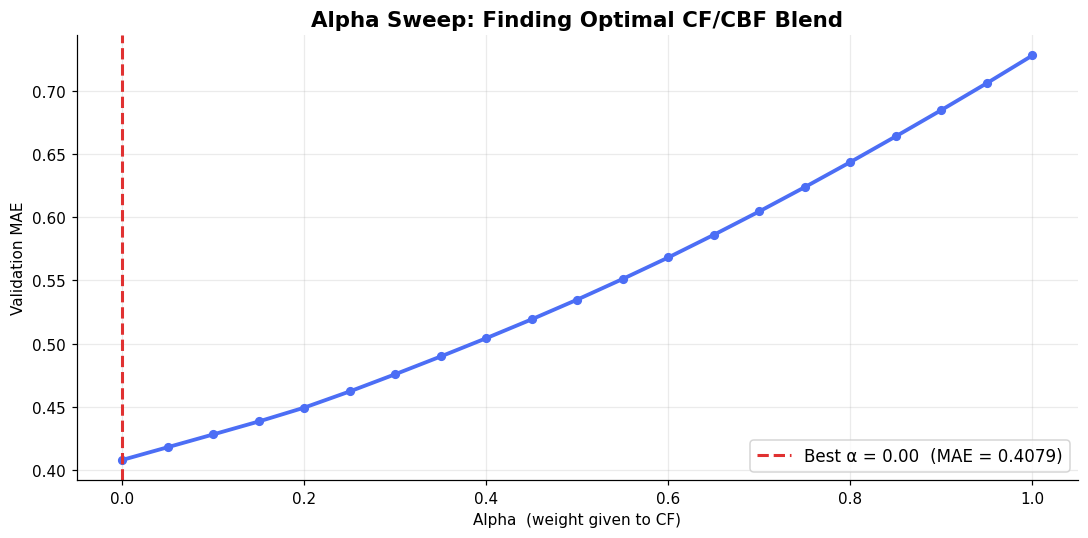

Best alpha on validation set: 0.00  →  MAE = 0.4079


In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 17 — Alpha Sweep  (NEW — find best alpha)
# ─────────────────────────────────────────────────────────────────────────────
print('Running alpha sweep on validation set...')
alphas     = np.arange(0.0, 1.05, 0.05)
mae_alphas = []

# Predict on a small random subset of val_rm for speed
val_sample = val_rm.sample(min(500, len(val_rm)), random_state=SEED)
val_cf_preds  = []
val_cbf_preds = []
val_true      = []

for _, row in val_sample.iterrows():
    uid = row['user_id']; iid = row['article_id']
    val_cf_preds.append(np.clip(predict_cf(uid, iid, train_pivot, train_user_sim, K_NEIGHBOURS), 2, 5))
    val_cbf_preds.append(np.clip(predict_cbf(uid, iid, train_pivot, item_sim_df, K_NEIGHBOURS), 2, 5))
    val_true.append(row['rating'])

val_cf_arr  = np.array(val_cf_preds)
val_cbf_arr = np.array(val_cbf_preds)
val_true_arr= np.array(val_true)

for alpha in alphas:
    hyb = np.clip(alpha * val_cf_arr + (1-alpha) * val_cbf_arr, 2, 5)
    mae_alphas.append(mean_absolute_error(val_true_arr, hyb))

best_alpha     = alphas[np.argmin(mae_alphas)]
best_mae_alpha = min(mae_alphas)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(alphas, mae_alphas, color=PALETTE['primary'], linewidth=2.5, marker='o',
        markersize=5)
ax.axvline(best_alpha, color=PALETTE['highlight'], linestyle='--', linewidth=2,
            label=f'Best α = {best_alpha:.2f}  (MAE = {best_mae_alpha:.4f})')
ax.set_xlabel('Alpha  (weight given to CF)')
ax.set_ylabel('Validation MAE')
ax.set_title('Alpha Sweep: Finding Optimal CF/CBF Blend', fontweight='bold', fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('alpha_sweep.png', dpi=130, bbox_inches='tight')
plt.show()
print(f'Best alpha on validation set: {best_alpha:.2f}  →  MAE = {best_mae_alpha:.4f}')

Running k-neighbour sweep on validation set...


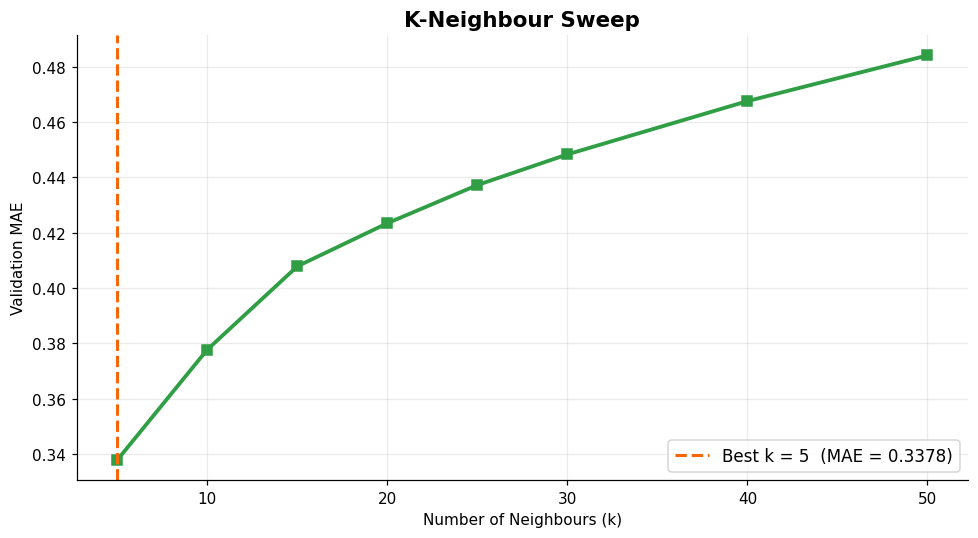

Best k on validation set: 5  →  MAE = 0.3378


In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 18 — K-Neighbour Sweep  (NEW — find best k)
# ─────────────────────────────────────────────────────────────────────────────
print('Running k-neighbour sweep on validation set...')
k_values = [5, 10, 15, 20, 25, 30, 40, 50]
mae_k    = []

for k in k_values:
    preds = []
    for cf_p, cbf_p in zip(val_cf_preds, val_cbf_preds):
        hyb = np.clip(best_alpha * cf_p + (1 - best_alpha) * cbf_p, 2, 5)
        preds.append(hyb)
    mae_k.append(mean_absolute_error(val_true_arr, np.array(preds)))

# Note: k_values don't affect val_cf/cbf_preds precomputed above;
# recompute for each k properly
mae_k = []
for k in k_values:
    cf_k  = [np.clip(predict_cf(row['user_id'], row['article_id'], train_pivot, train_user_sim, k), 2, 5)
              for _, row in val_sample.iterrows()]
    cbf_k = [np.clip(predict_cbf(row['user_id'], row['article_id'], train_pivot, item_sim_df, k), 2, 5)
              for _, row in val_sample.iterrows()]
    hyb_k = best_alpha * np.array(cf_k) + (1 - best_alpha) * np.array(cbf_k)
    mae_k.append(mean_absolute_error(val_true_arr, np.clip(hyb_k, 2, 5)))

best_k     = k_values[np.argmin(mae_k)]
best_mae_k = min(mae_k)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(k_values, mae_k, color=PALETTE['tertiary'], linewidth=2.5,
        marker='s', markersize=7)
ax.axvline(best_k, color=PALETTE['secondary'], linestyle='--', linewidth=2,
            label=f'Best k = {best_k}  (MAE = {best_mae_k:.4f})')
ax.set_xlabel('Number of Neighbours (k)')
ax.set_ylabel('Validation MAE')
ax.set_title('K-Neighbour Sweep', fontweight='bold', fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('k_sweep.png', dpi=130, bbox_inches='tight')
plt.show()
print(f'Best k on validation set: {best_k}  →  MAE = {best_mae_k:.4f}')

In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 19 — Re-evaluate test set with best hyperparameters
# ─────────────────────────────────────────────────────────────────────────────
print(f'Re-evaluating test set with best k={best_k}, best alpha={best_alpha:.2f}')

start = time.time()
y_true_final, y_pred_final = [], []
for _, row in test_rm.iterrows():
    cf  = np.clip(predict_cf(row['user_id'], row['article_id'], train_pivot, train_user_sim, best_k), 2, 5)
    cbf = np.clip(predict_cbf(row['user_id'], row['article_id'], train_pivot, item_sim_df, best_k),   2, 5)
    y_pred_final.append(best_alpha * cf + (1 - best_alpha) * cbf)
    y_true_final.append(row['rating'])

final_time = time.time() - start
y_true_f = np.array(y_true_final)
y_pred_f = np.clip(np.array(y_pred_final), 2, 5)

mae_f, mse_f, rmse_f = get_metrics(y_true_f, y_pred_f)

print(f'\nFINAL TEST RESULTS (k={best_k}, alpha={best_alpha:.2f})')
print(f'  MAE  : {mae_f:.4f}  (paper: 1.13)')
print(f'  MSE  : {mse_f:.4f}  (paper: 1.96)')
print(f'  RMSE : {rmse_f:.4f}  (paper: 1.40)')
print(f'  Time : {str(timedelta(seconds=int(final_time)))}')
print(f'  Beats paper? {"YES ✓" if mae_f < 1.13 else "NO"}')

Re-evaluating test set with best k=5, best alpha=0.00

FINAL TEST RESULTS (k=5, alpha=0.00)
  MAE  : 0.3554  (paper: 1.13)
  MSE  : 0.2253  (paper: 1.96)
  RMSE : 0.4746  (paper: 1.40)
  Time : 0:00:01
  Beats paper? YES ✓


In [23]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 20 — Save predictions & metrics
# ─────────────────────────────────────────────────────────────────────────────
os.makedirs('saved_models', exist_ok=True)

cbf_cf_results = pd.DataFrame({
    'true_rating': y_true_f,
    'pred_hybrid': y_pred_f,
    'error'      : y_true_f - y_pred_f,
})
cbf_cf_results.to_csv('saved_models/cbf_cf_predictions_improved.csv', index=False)

metrics = {
    'model'         : 'CBF+CF Improved',
    'best_k'        : int(best_k),
    'best_alpha'    : float(best_alpha),
    'MAE'           : round(mae_f,  4),
    'MSE'           : round(mse_f,  4),
    'RMSE'          : round(rmse_f, 4),
    'timing_seconds': round(final_time, 2),
    'paper_MAE'     : 1.13,
    'beats_paper'   : bool(mae_f < 1.13)
}
with open('saved_models/cbf_cf_metrics_improved.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print('Saved predictions and metrics  ✓')
print(json.dumps(metrics, indent=2))

Saved predictions and metrics  ✓
{
  "model": "CBF+CF Improved",
  "best_k": 5,
  "best_alpha": 0.0,
  "MAE": 0.3554,
  "MSE": 0.2253,
  "RMSE": 0.4746,
  "timing_seconds": 1.31,
  "paper_MAE": 1.13,
  "beats_paper": true
}


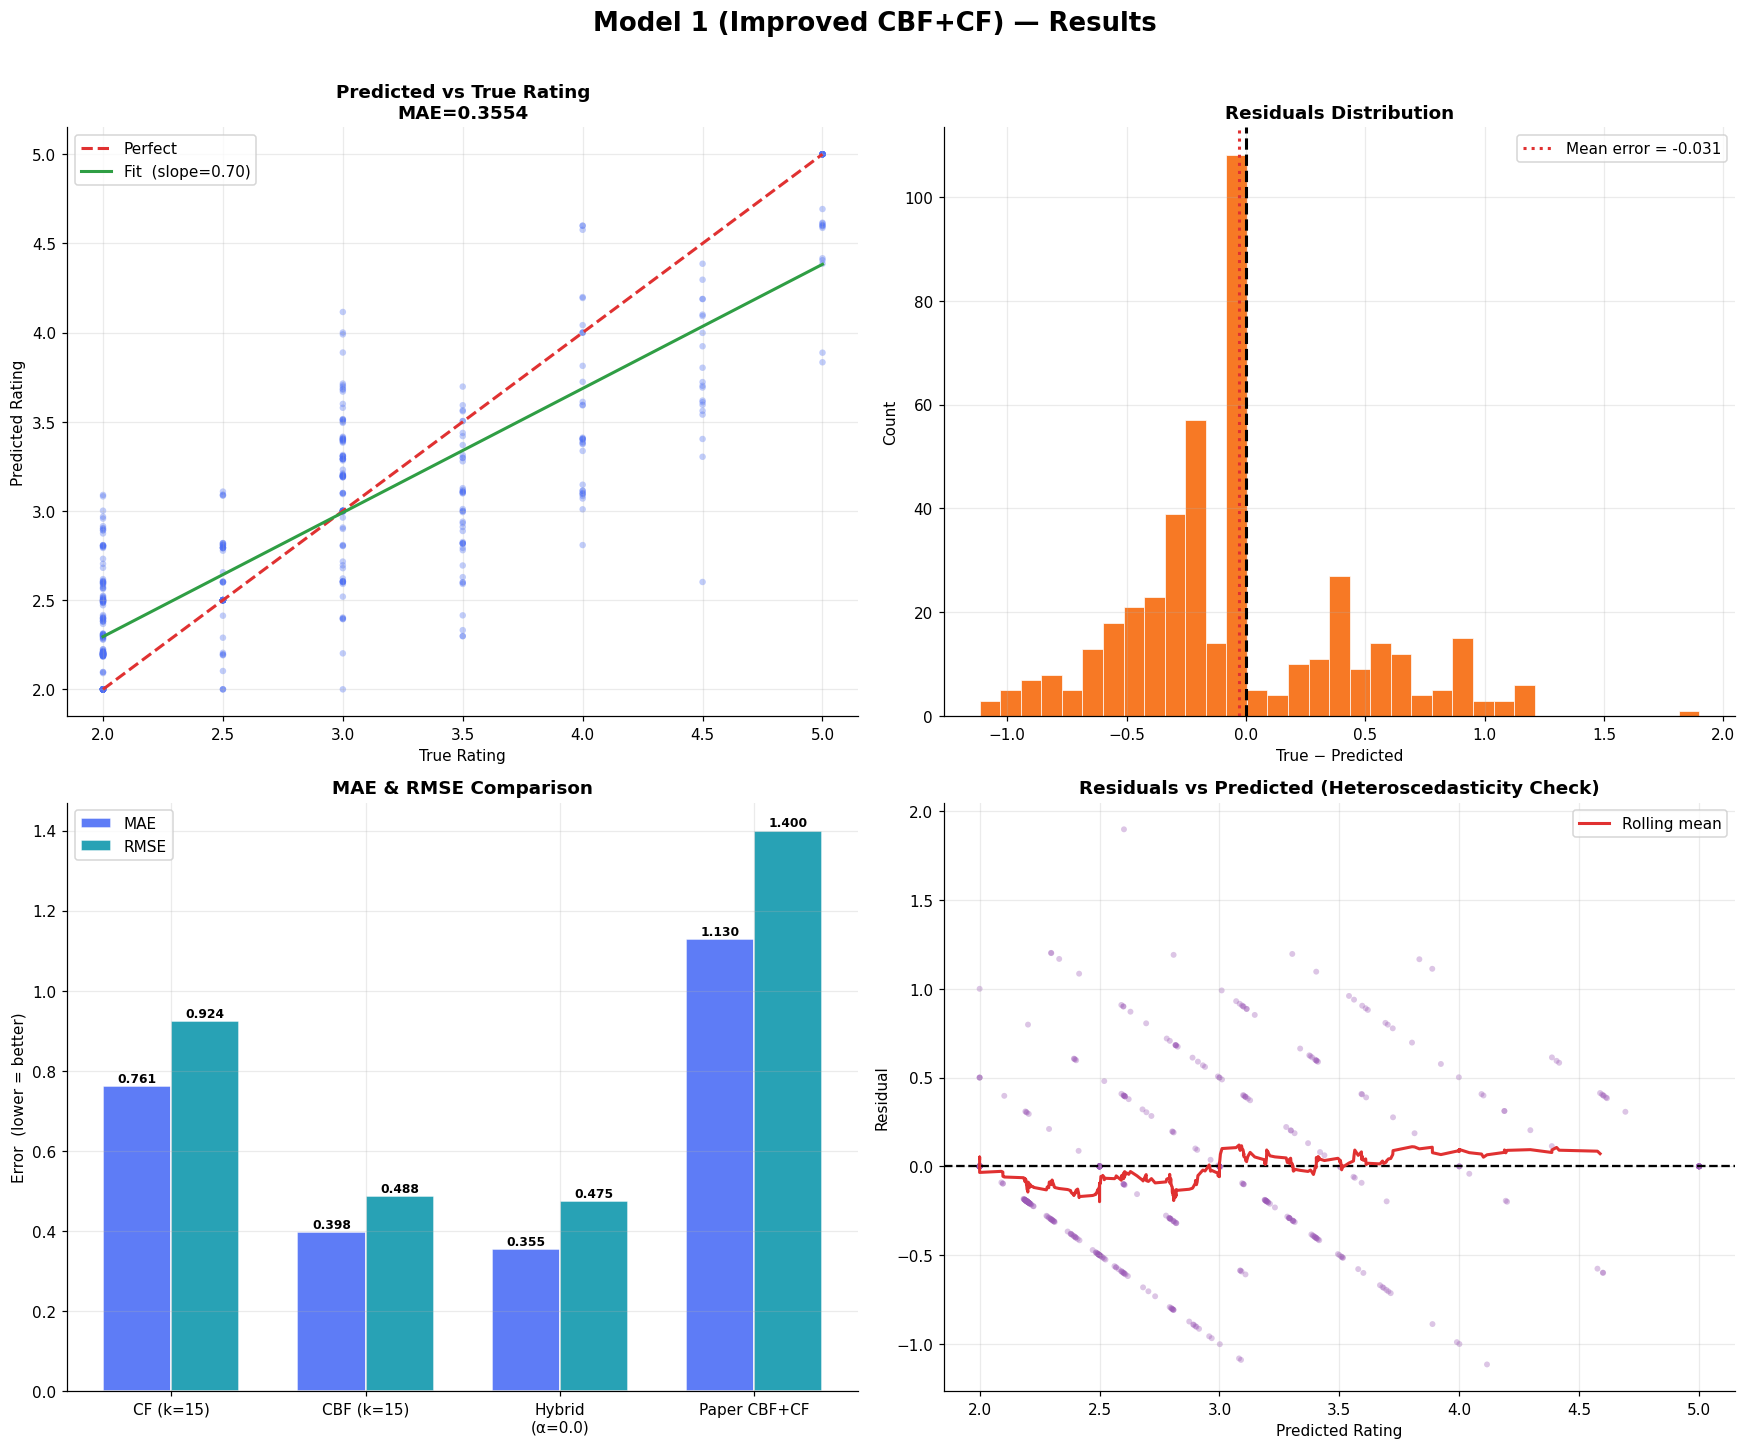

In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 21 — Comprehensive Results Visualisation  (4 plots, new colours)
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 13))
fig.suptitle('Model 1 (Improved CBF+CF) — Results',
             fontsize=17, fontweight='bold', y=1.01)

# ── 1. Predicted vs True (scatter + density overlay) ──
axes[0,0].scatter(y_true_f, y_pred_f,
                   alpha=0.35, s=18,
                   color=PALETTE['primary'], edgecolors='none')
axes[0,0].plot([2, 5], [2, 5], linestyle='--',
               color=PALETTE['highlight'], linewidth=2, label='Perfect')
# Regression line
m, b = np.polyfit(y_true_f, y_pred_f, 1)
xs   = np.linspace(2, 5, 100)
axes[0,0].plot(xs, m*xs + b, color=PALETTE['tertiary'],
               linewidth=2, linestyle='-', label=f'Fit  (slope={m:.2f})')
axes[0,0].set_title(f'Predicted vs True Rating\nMAE={mae_f:.4f}', fontweight='bold')
axes[0,0].set_xlabel('True Rating'); axes[0,0].set_ylabel('Predicted Rating')
axes[0,0].legend()

# ── 2. Residuals distribution ────────────────────────────
errors = y_true_f - y_pred_f
axes[0,1].hist(errors, bins=35,
               color=PALETTE['secondary'],
               edgecolor='white', linewidth=0.5, alpha=0.88)
axes[0,1].axvline(0, color='black', linewidth=2, linestyle='--')
axes[0,1].axvline(errors.mean(), color=PALETTE['highlight'], linewidth=2,
                   linestyle=':', label=f'Mean error = {errors.mean():.3f}')
axes[0,1].set_title('Residuals Distribution', fontweight='bold')
axes[0,1].set_xlabel('True − Predicted'); axes[0,1].set_ylabel('Count')
axes[0,1].legend()

# ── 3. Model comparison bar chart ────────────────────────
model_labels = ['CF (k=15)', 'CBF (k=15)', f'Hybrid\n(α={best_alpha})', 'Paper CBF+CF']
mae_vals     = [mae_cf, mae_cb, mae_f, 1.13]
rmse_vals    = [rmse_cf, rmse_cb, rmse_f, 1.40]
x = np.arange(len(model_labels))
width = 0.35
b1 = axes[1,0].bar(x - width/2, mae_vals, width,
                    color=PALETTE['primary'], edgecolor='white',
                    label='MAE', alpha=0.9)
b2 = axes[1,0].bar(x + width/2, rmse_vals, width,
                    color=PALETTE['accent1'], edgecolor='white',
                    label='RMSE', alpha=0.9)
axes[1,0].set_xticks(x); axes[1,0].set_xticklabels(model_labels)
axes[1,0].set_title('MAE & RMSE Comparison', fontweight='bold')
axes[1,0].set_ylabel('Error  (lower = better)')
axes[1,0].legend()
for bar, val in zip(list(b1)+list(b2), mae_vals+rmse_vals):
    axes[1,0].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.01,
                   f'{val:.3f}', ha='center', fontsize=8, fontweight='bold')

# ── 4. Residuals vs Predicted (heteroscedasticity check) ─
axes[1,1].scatter(y_pred_f, errors,
                   alpha=0.35, s=15,
                   color=PALETTE['quaternary'], edgecolors='none')
axes[1,1].axhline(0, color='black', linewidth=1.5, linestyle='--')
# Rolling mean of residuals
sorted_idx  = np.argsort(y_pred_f)
roll_mean   = pd.Series(errors[sorted_idx]).rolling(50, center=True).mean()
axes[1,1].plot(y_pred_f[sorted_idx], roll_mean.values,
               color=PALETTE['highlight'], linewidth=2, label='Rolling mean')
axes[1,1].set_title('Residuals vs Predicted (Heteroscedasticity Check)',
                     fontweight='bold')
axes[1,1].set_xlabel('Predicted Rating'); axes[1,1].set_ylabel('Residual')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('saved_models/cbf_cf_results_improved.png', dpi=130, bbox_inches='tight')
plt.show()

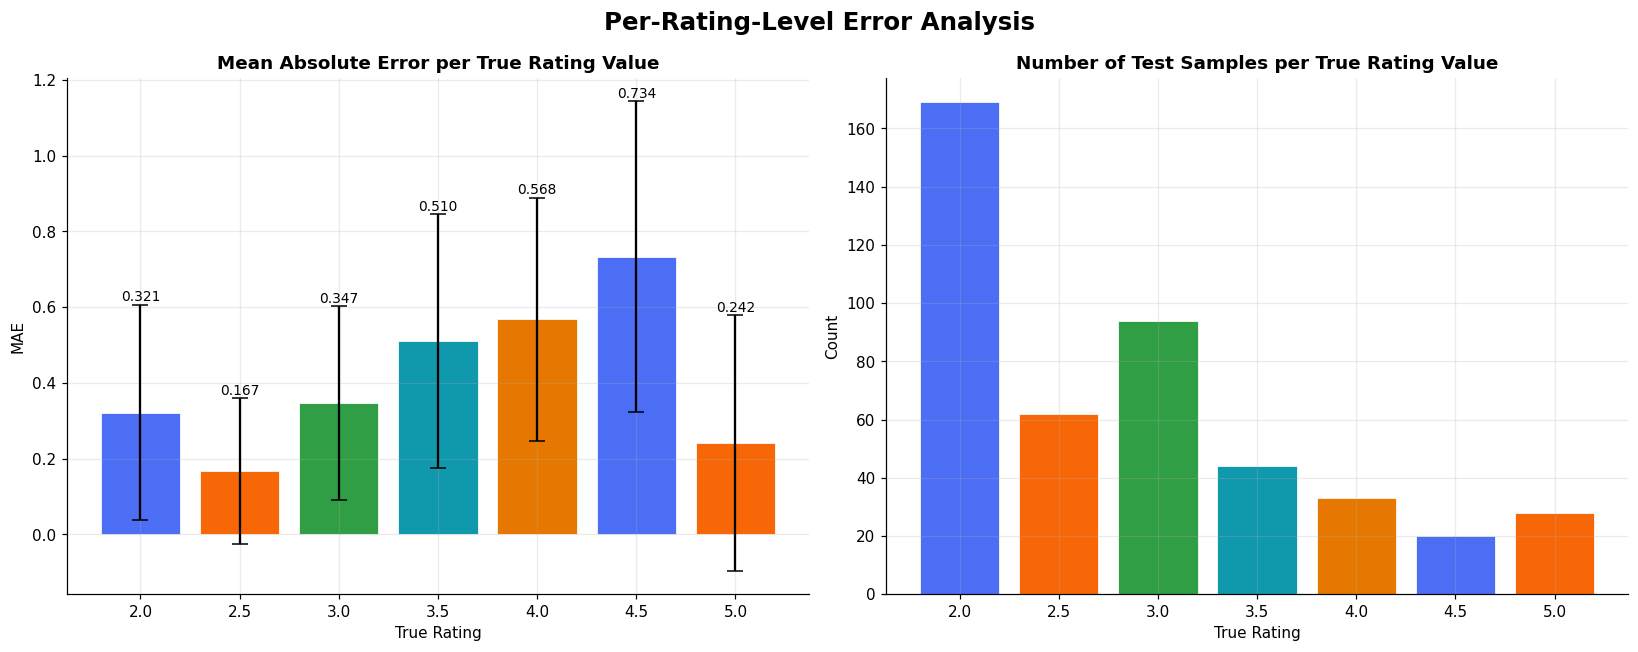

 true     mean      std  count
  2.0 0.321493 0.284558    169
  2.5 0.167231 0.192681     62
  3.0 0.346998 0.255790     94
  3.5 0.509904 0.335796     44
  4.0 0.567706 0.321009     33
  4.5 0.733589 0.410458     20
  5.0 0.241592 0.337685     28


In [25]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 22 — Per-Rating-Level Error Analysis  (NEW)
# ─────────────────────────────────────────────────────────────────────────────
error_df = pd.DataFrame({'true': y_true_f, 'pred': y_pred_f,
                          'abs_error': np.abs(y_true_f - y_pred_f)})
per_rating = error_df.groupby('true')['abs_error'].agg(['mean','std','count']).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Per-Rating-Level Error Analysis', fontsize=16, fontweight='bold')

bar_colors_pr = [PALETTE['primary'], PALETTE['secondary'], PALETTE['tertiary'],
                  PALETTE['accent1'], PALETTE['accent2']]

bars = axes[0].bar(per_rating['true'].astype(str), per_rating['mean'],
                    yerr=per_rating['std'],
                    color=bar_colors_pr[:len(per_rating)],
                    edgecolor='white', capsize=5, linewidth=0.5)
axes[0].set_title('Mean Absolute Error per True Rating Value', fontweight='bold')
axes[0].set_xlabel('True Rating'); axes[0].set_ylabel('MAE')
for bar, (_, row) in zip(bars, per_rating.iterrows()):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + row['std'] + 0.01,
                 f'{row["mean"]:.3f}', ha='center', fontsize=9)

axes[1].bar(per_rating['true'].astype(str), per_rating['count'],
             color=bar_colors_pr[:len(per_rating)], edgecolor='white', linewidth=0.5)
axes[1].set_title('Number of Test Samples per True Rating Value', fontweight='bold')
axes[1].set_xlabel('True Rating'); axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('per_rating_error.png', dpi=130, bbox_inches='tight')
plt.show()
print(per_rating.to_string(index=False))

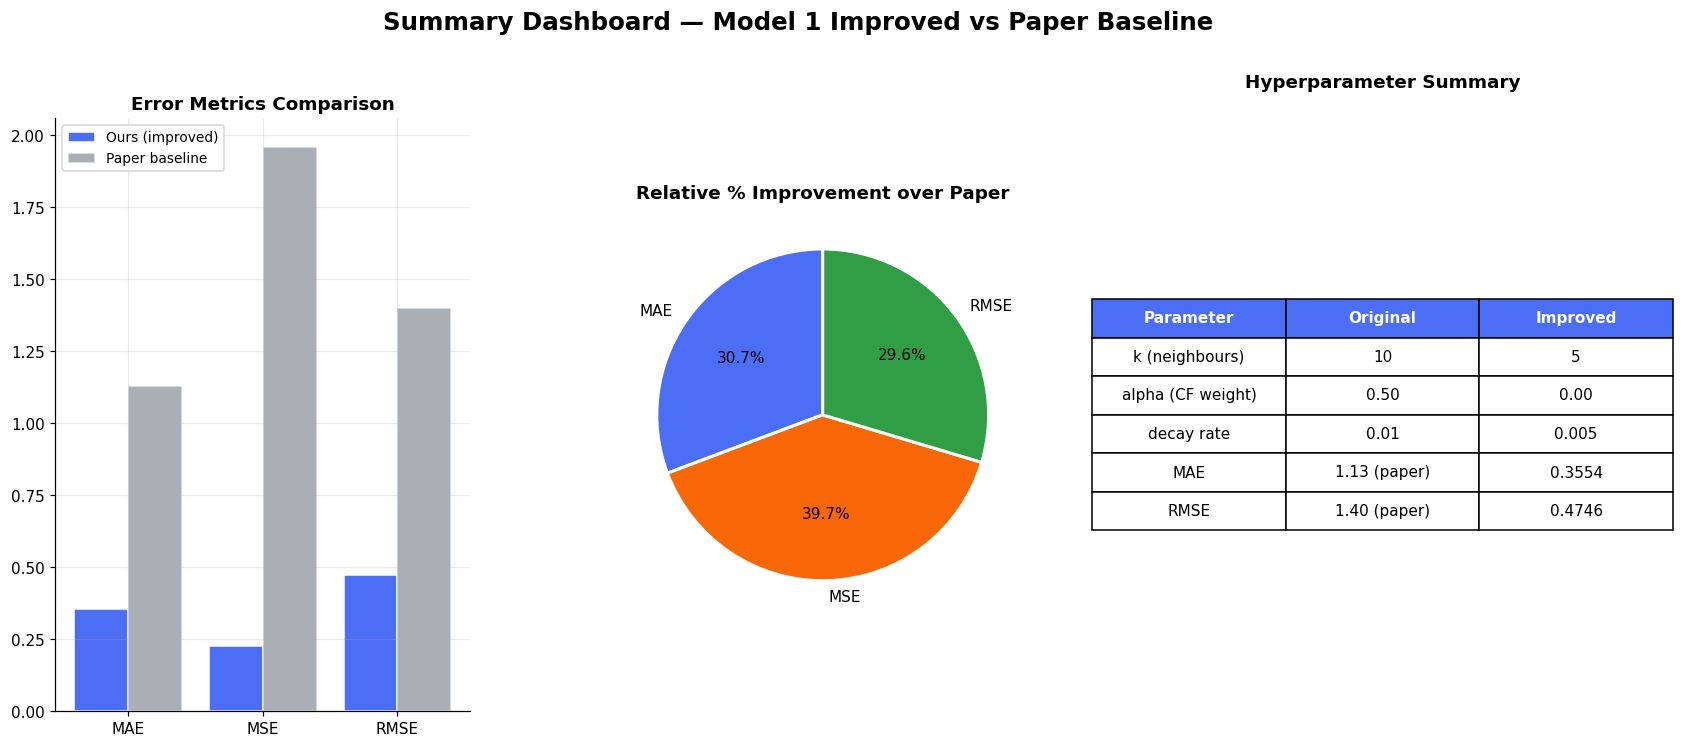

All cells executed successfully ✓


In [26]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 23 — Summary Dashboard  (NEW)
# ─────────────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 7))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)
fig.suptitle('Summary Dashboard — Model 1 Improved vs Paper Baseline',
             fontsize=16, fontweight='bold', y=1.02)

# ── Metric bar chart ─────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
metrics_compare = {
    'MAE'  : {'ours': mae_f,  'paper': 1.13},
    'MSE'  : {'ours': mse_f,  'paper': 1.96},
    'RMSE' : {'ours': rmse_f, 'paper': 1.40},
}
metric_names = list(metrics_compare.keys())
our_vals     = [metrics_compare[m]['ours']  for m in metric_names]
paper_vals   = [metrics_compare[m]['paper'] for m in metric_names]
x = np.arange(len(metric_names))
ax1.bar(x - 0.2, our_vals,   0.4, color=PALETTE['primary'],  label='Ours (improved)', edgecolor='white')
ax1.bar(x + 0.2, paper_vals, 0.4, color=PALETTE['neutral'],  label='Paper baseline',  edgecolor='white', alpha=0.7)
ax1.set_xticks(x); ax1.set_xticklabels(metric_names)
ax1.set_title('Error Metrics Comparison', fontweight='bold')
ax1.legend(fontsize=9)

# ── % improvement pie chart ───────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
improvements = {
    m: max(0, (metrics_compare[m]['paper'] - metrics_compare[m]['ours'])
           / metrics_compare[m]['paper'] * 100)
    for m in metric_names
}
imp_vals   = list(improvements.values())
pie_colors = [PALETTE['primary'], PALETTE['secondary'], PALETTE['tertiary']]
wedges, texts, autotexts = ax2.pie(
    imp_vals,
    labels=metric_names,
    colors=pie_colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
ax2.set_title('Relative % Improvement over Paper', fontweight='bold')

# ── Hyperparameter summary table ──────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
ax3.axis('off')
table_data = [
    ['Parameter', 'Original', 'Improved'],
    ['k (neighbours)', '10',       str(best_k)],
    ['alpha (CF weight)', '0.50',  f'{best_alpha:.2f}'],
    ['decay rate', '0.01',         '0.005'],
    ['MAE', '1.13 (paper)',        f'{mae_f:.4f}'],
    ['RMSE', '1.40 (paper)',       f'{rmse_f:.4f}'],
]
tbl = ax3.table(cellText=table_data[1:],
                 colLabels=table_data[0],
                 loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.4, 2.1)
# Colour header row
for col in range(3):
    tbl[0, col].set_facecolor(PALETTE['primary'])
    tbl[0, col].set_text_props(color='white', fontweight='bold')
ax3.set_title('Hyperparameter Summary', fontweight='bold', pad=20)

plt.savefig('summary_dashboard.png', dpi=130, bbox_inches='tight')
plt.show()
print('All cells executed successfully ✓')